In [1]:
import pandas as pd
import glob 
import numpy as np
import protfasta
from ete4 import Tree
from ete4.treeview import TreeStyle, TextFace

In [7]:
interpro = pd.read_csv("../data/interpro_tf_doms_7-22-25.csv")
interpro["Interpro superfamily domain code"] = interpro["Interpro superfamily domain code"].str.strip().fillna(interpro["Interpro domain code"])
interpro

,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,Interpro superfamily domain code
0,C2H2 ZF(non-KRAB),Zinc finger C2H2-type,IPR013087,Zinc finger C2H2 superfamily,IPR036236
1,C2H2 ZF(KRAB),Zinc finger C2H2-type,IPR013087,Zinc finger C2H2 superfamily,IPR036236
2,Homeodomain,Homeodomain,IPR001356,Homedomain-like superfamily,IPR009057
3,bHLH,"Myc-type, basic helix-loop-helix (bHLH) domain",IPR011598,Helix-loop-helix DNA-binding domain superfamily,IPR036638
4,bZIP,Basic-leucine zipper domain,IPR004827,Basic-leucine zipper domain superfamily,IPR046347
5,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,IPR036388
6,Nuclear receptor,"Nuclear hormone receptor, ligand-binding domain",IPR000536,Nuclear hormone receptor-like domain superfamily,IPR035500
7,HMG/Sox,High mobility group box domain,IPR009071,High mobility group box domain superfamily,IPR036910
8,Ets,Ets domain,IPR000418,Winged helix-like DNA-binding domain superfamily,IPR036388
9,T-box,"T-box transcription factor, DNA-binding domain",IPR046360,T-box superfamily,IPR036960


In [12]:
all_dfs = []

for path in glob.glob("../data/interpro_uniprot_downloads/IPR*"):
    fasta_dict = protfasta.read_fasta(path, invalid_sequence_action = 'remove')
    path_df = pd.DataFrame({"path" : path, "id" : fasta_dict.keys(), "seq" : fasta_dict.values(), "evidence" : "protein"})
    all_dfs.append(path_df)

for path in glob.glob("../data/interpro_uniprot_downloads/transcript_evidence/*"):
    fasta_dict = protfasta.read_fasta(path, invalid_sequence_action = 'remove')
    path_df = pd.DataFrame({"path" : path, "id" : fasta_dict.keys(), "seq" : fasta_dict.values(), "evidence" : "transcript"})
    all_dfs.append(path_df)

all_dfs = pd.concat(all_dfs)
all_dfs["Interpro superfamily domain code"] = all_dfs["path"].str.split("/").str[-1].str.split(".").str[0]
# Drop dups 
all_dfs = all_dfs.drop_duplicates(subset = "seq")
all_dfs["len"] = all_dfs["seq"].str.len()
all_dfs = all_dfs[all_dfs["len"] >= 53]
all_dfs = all_dfs[all_dfs["len"] <= 1891]
all_dfs

,path,id,seq,evidence,Interpro superfamily domain code,len
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610
...,...,...,...,...,...,...
5736,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300
5737,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939
5738,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294
5739,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329


In [16]:
# Keep rows with desired codes
seqs_with_codes = pd.merge(all_dfs, interpro, on = "Interpro superfamily domain code")
seqs_with_codes["name"] = seqs_with_codes["id"].str.split("|").str[2]
seqs_with_codes["Interpro domain name shortened"] = seqs_with_codes["Interpro domain name"].str.replace(" domain", "")
seqs_with_codes = seqs_with_codes.drop_duplicates(subset = "seq")
seqs_with_codes["uniprotID"] = seqs_with_codes["id"].str.split("|").str[1]
seqs_with_codes

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
334932,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846
334933,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25
334934,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6
334935,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7


In [ ]:
interpro_species = pd.read_csv("../data/interpro_seq_species.txt", sep = "\t")
interpro_species = interpro_species.rename(columns = {"From" : "uniprotID"})
interpro_species = interpro_species.drop(columns = "Entry")
interpro_species = interpro_species[interpro_species["uniprotID"].isin(seqs_with_codes["uniprotID"])]
interpro_species["Organism"] = interpro_species["Organism"].str.split(" \(").str[0]
interpro_species["Organism"] = interpro_species["Organism"].str.split(" serotype").str[0]
interpro_species["Organism"] = interpro_species["Organism"].str.split(" serovar").str[0]
interpro_species

<>:5: SyntaxWarning: invalid escape sequence '\('
<>:5: SyntaxWarning: invalid escape sequence '\('
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_27961/1199476015.py:5: SyntaxWarning: invalid escape sequence '\('
  interpro_species["Organism"] = interpro_species["Organism"].str.split(" \(").str[0]


,uniprotID,Organism
1,A1L0Z1,Xenopus tropicalis
2,A7Y7W2,Gallus gallus
3,B3DM23,Xenopus tropicalis
4,B3DM25,Xenopus tropicalis
5,B7ZQA9,Xenopus laevis
...,...,...
12777,Q9Y2D1,Homo sapiens
12778,Q9Y4A8,Homo sapiens
12779,Q9Y5Q3,Homo sapiens
12780,Q9Z125,Mus musculus


In [124]:
interpro_species[["Organism"]].to_csv("../data/input_data_species.txt", index=False, header=False)

In [150]:
def levels_from_root(node):
    if node.is_root: 
        return 0
    else:
        return 1 + levels_from_root(node.up)

In [151]:
def total_children(node):
    if len(node.children) == 0:
        return 0
    else:
        return len(node.children) + sum([total_children(child) for child in node.children])

root
Viruses
cellular organisms
Captovirus AFV1
Avian sarcoma virus
Heunggongvirae
Chordopoxvirinae
Eukaryota
Archaea
Bacteria
Caudoviricetes
Orthoherpesviridae
Yaba-like disease virus
Orthopoxvirus
Amoebozoa
Trypanosomatidae
Opisthokonta
Sar
Viridiplantae
Thermoprotei
Methanobacteriati
unidentified prokaryotic organism
Thermotogati
Bacillati
Pseudomonadati


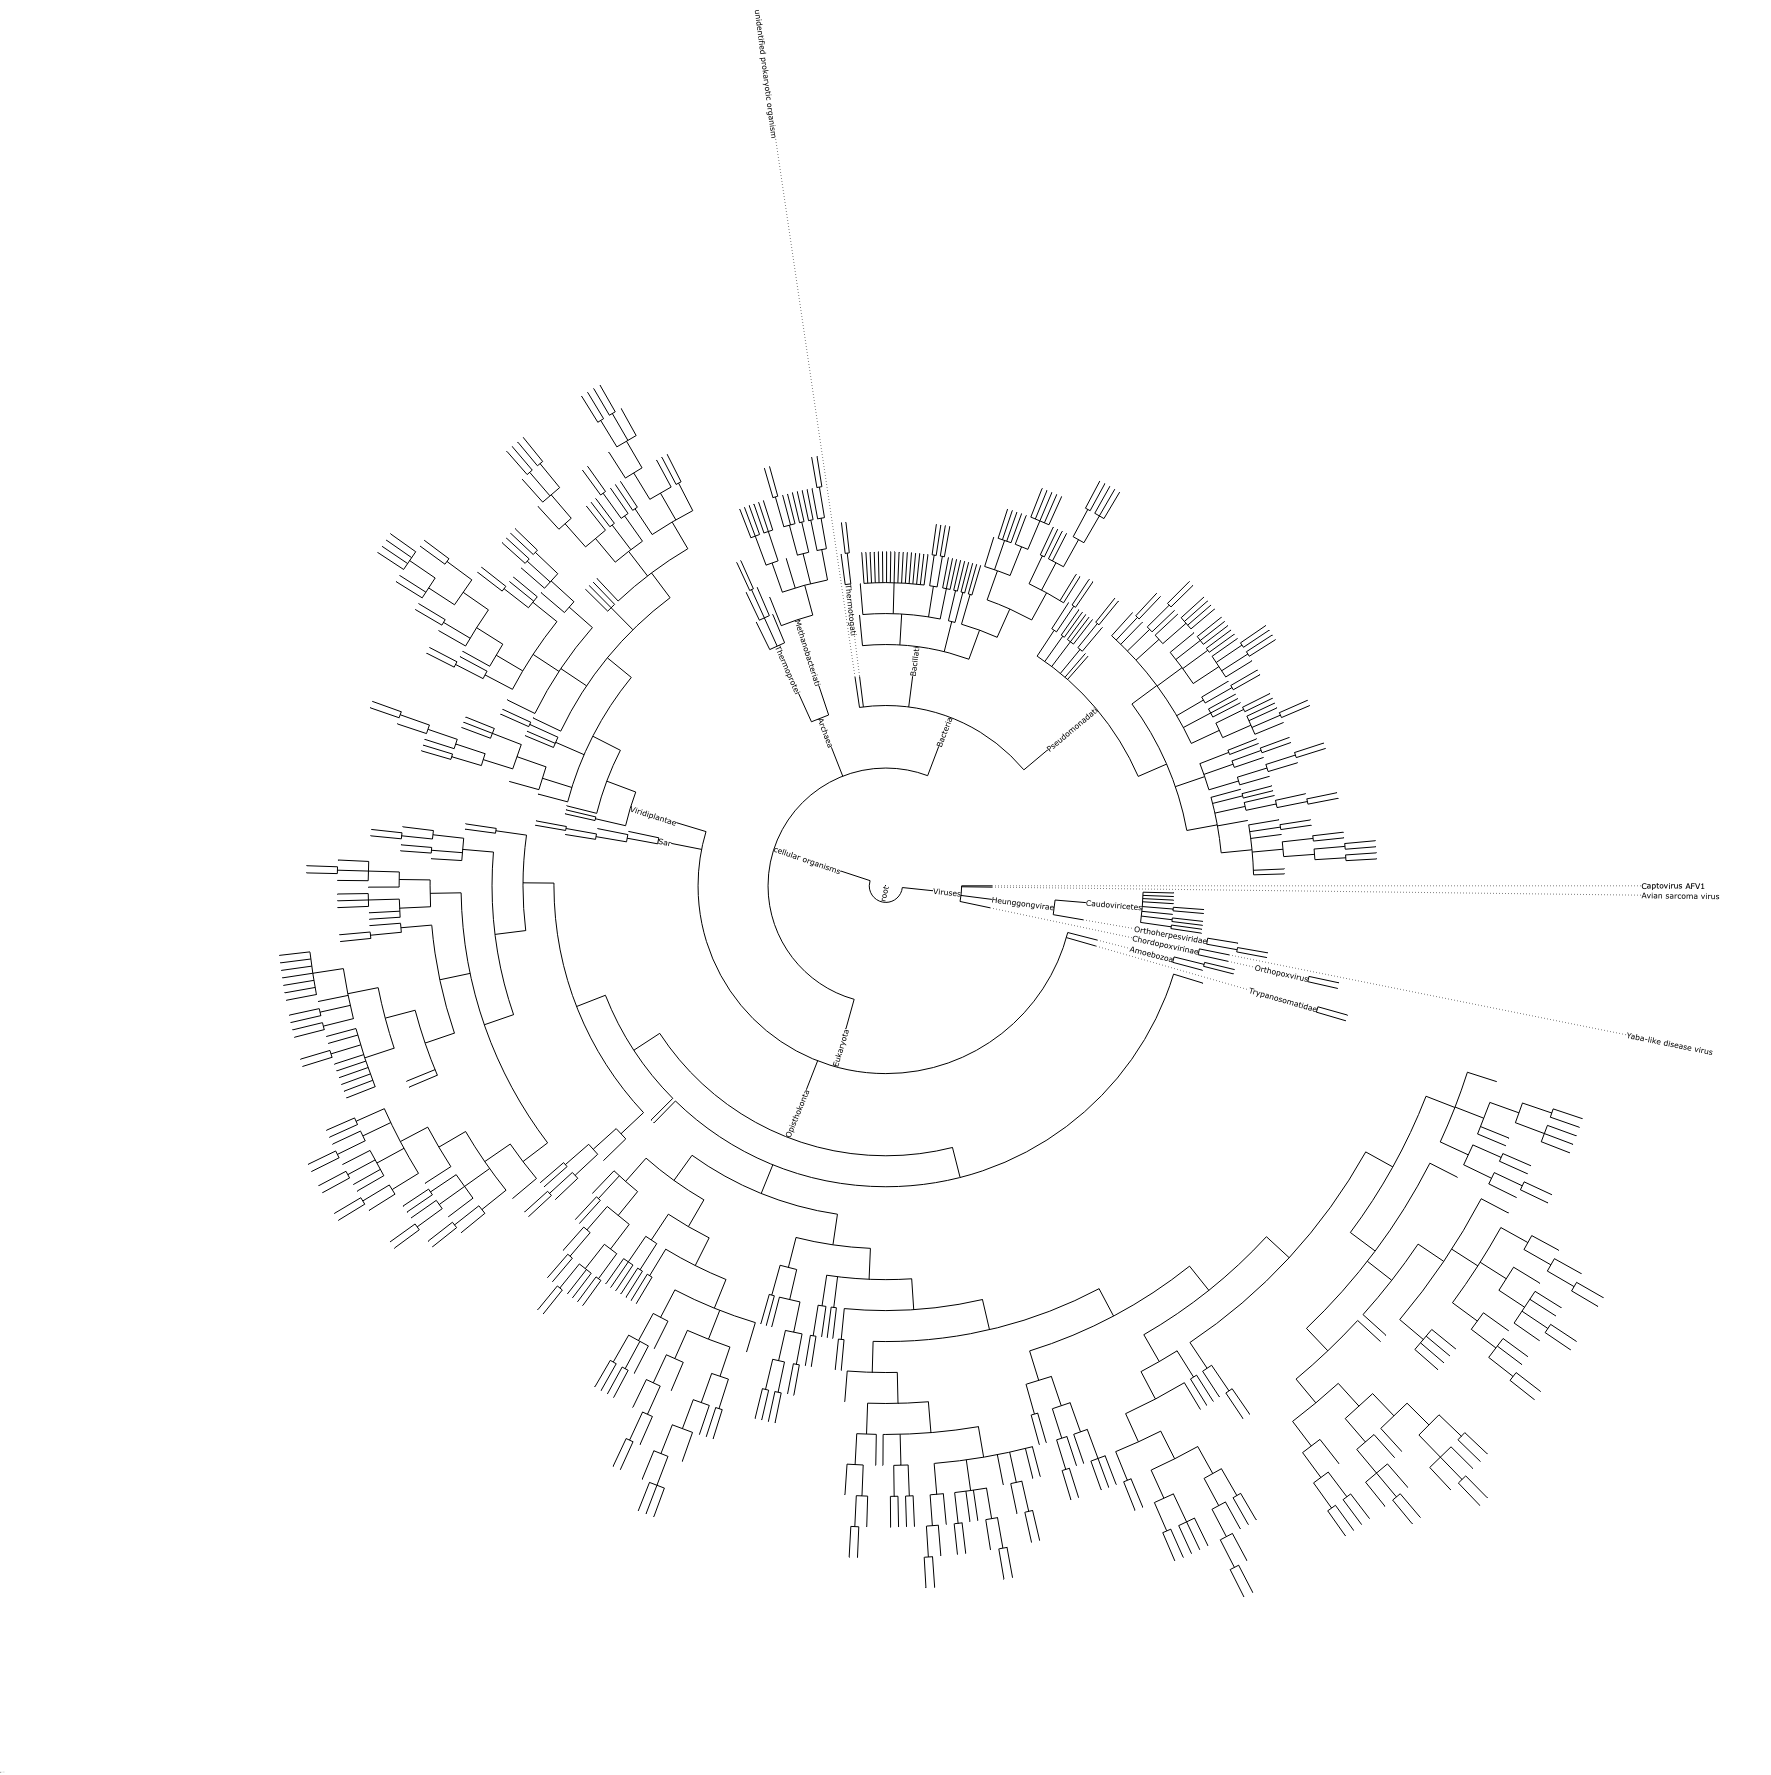

In [163]:
t = Tree(open("../data/training_data_phyliptree.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False


for node in t.traverse():
    node_from_root = levels_from_root(node)
    if node_from_root <= 3:
        print(node.name)
        size = 100 #min(500, 10 + node_from_root // 4)  # Cap size to 80
        tf = TextFace(f"{node.name}", fsize=size)
        tf.rotation = 0
        node.add_face(tf, column=0, position="branch-right")
        # # Calculate angle of node (ete3 provides node._angle in circular mode)
        # if hasattr(node, "_angle"):
        #     angle = node._angle
        # else:
        #     # fallback if not precomputed
        #     continue

        # # Rotate text to match radial layout
        # tf.rotation = angle if angle < 180 else angle - 180
        # tf.rotation = (tf.rotation + 90) % 360  # Adjust for upright readability


t.render('%%inline', w=150, units='mm', tree_style=circular_style, dpi = 300)


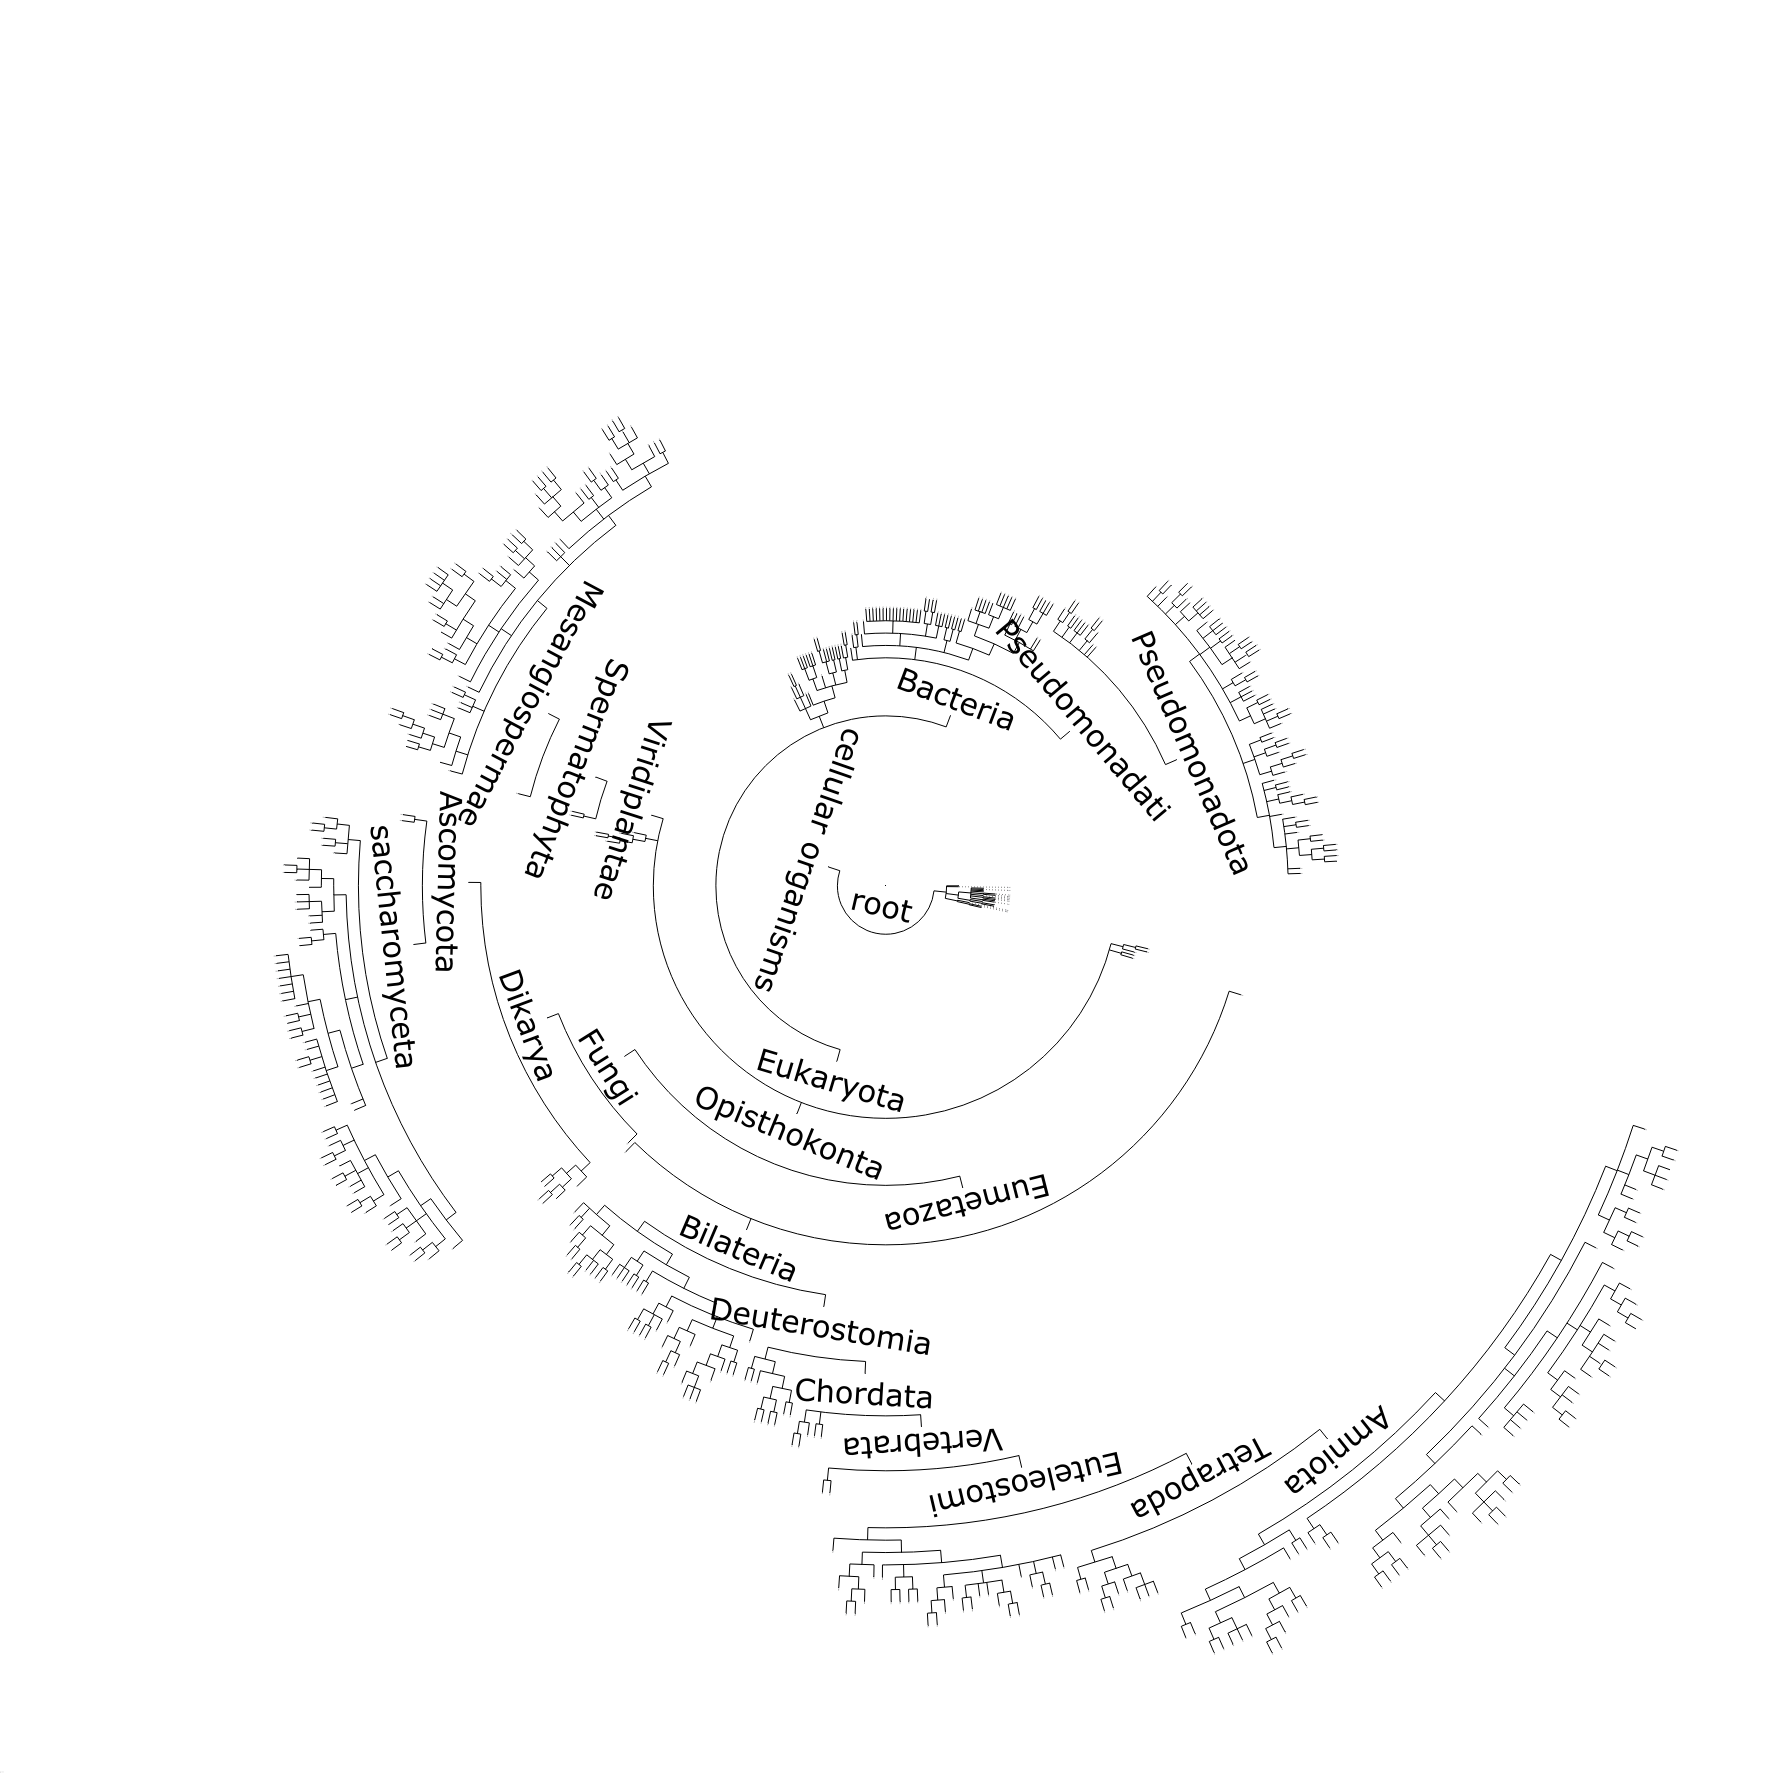

In [164]:
t = Tree(open("../data/training_data_phyliptree.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 50
circular_style.show_branch_length = False
circular_style.show_branch_support = False


for node in t.traverse():
    node_children = total_children(node)
    if node_children >= 100:
        size = 500 #min(500, 10 + node_children // 4)  # Cap size to 80
        tf = TextFace(f"{node.name}", fsize=size)
        tf.rotation = 90
        node.add_face(tf, column=0, position="branch-right")
        # # Calculate angle of node (ete3 provides node._angle in circular mode)
        # if hasattr(node, "_angle"):
        #     angle = node._angle
        # else:
        #     # fallback if not precomputed
        #     continue

        # # Rotate text to match radial layout
        # tf.rotation = angle if angle < 180 else angle - 180
        # tf.rotation = (tf.rotation + 90) % 360  # Adjust for upright readability

    if node.name in set(interpro_species["Organism"]):
        size = 20 #min(500, 10 + node_children // 4)  # Cap size to 80
        tf = TextFace(f"{(str(node.name))[:3]}", fsize=size)
        tf.rotation = 0
        node.add_face(tf, column=0, position="branch-right")

t.render('%%inline', w=150, units='mm', tree_style=circular_style, dpi = 300)
